# Decision Tree Classifier (explicit if-else rules)
**Data:** Temporally split parquets (`train_t03`, `val_t03`, `test_t03`)  
**Target:** `Results` --> `1 = Fail`, `0 = Pass`

### Modelling Flow
1. Load temporally-split parquets (train_t03, val_t03, test_t03)
2. Baseline Decision Tree (default hyperparameters)
   - Establishes a lower-bound reference score
3. Hyperparameter Tuning via RandomizedSearchCV + PredefinedSplit
   - Randomly samples 80 combinations from the search space
   - PredefinedSplit enforces our temporal split during search (no shuffling)
   - Scored on F1-weighted to account for class imbalance (70% Pass / 30% Fail)
4. Refit best model on train only
   - Best params applied to a clean model trained on past data only
5. Evaluate on Val → Test
   - Val: used during development to monitor performance
   - Test: final honest evaluation, touched only once
6. Interpret results
   - Confusion matrix, feature importances, tree visualization

### Class Imbalance Handling
The training set is imbalanced (**70.5% Pass, 29.5% Fail**). The tuner selected
`class_weight='balanced'`, which internally re-weights each class inversely proportional
to its frequency — making the model pay more attention to the minority Fail class
instead of defaulting to always predicting Pass.

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score,
    accuracy_score,
)
from scipy.stats import randint

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42   # a fixed seed so results are reproducible every run
TARGET = 'Results'  # 1 = Fail, 0 = Pass

## 2. Load Data

In [2]:
BASE = '../../data/transformed'

train = pd.read_parquet(f'{BASE}/train_t03.parquet')
val   = pd.read_parquet(f'{BASE}/val_t03.parquet')
test  = pd.read_parquet(f'{BASE}/test_t03.parquet')

print(f'Train : {train.shape}')
print(f'Val   : {val.shape}')
print(f'Test  : {test.shape}')

Train : (109693, 17)
Val   : (27483, 17)
Test  : (34294, 17)


## 3. Prepare Features & Target

In [ ]:
def prepare(df, target=TARGET):
    """Separates features from target: split into X: features, y: target & cast bool columns to int. """
    X = df.drop(columns=[target]).copy() # features
    
    # has_prior_inspection is bool — cast to int for sklearn
    bool_cols = X.select_dtypes(include='bool').columns
    X[bool_cols] = X[bool_cols].astype(int)
    
    y = df[target] # target (Results: 1=Fail, 0=Pass)
    return X, y

X_train, y_train = prepare(train)
X_val,   y_val   = prepare(val)
X_test,  y_test  = prepare(test)

print('Features:', X_train.columns.tolist())
print(f'\nClass distribution in train (1=Fail, 0=Pass):')
print(y_train.value_counts(normalize=True).round(3))

Features: ['Risk', 'has_prior_inspection', 'violation_count', 'inspection_year', 'inspection_month', 'inspection_dayofweek', 'inspection_quarter', 'days_to_license_expiry', 'license_expiry_missing', 'days_since_last_inspection', 'prev_inspection_result', 'fail_rate_last_3', 'inspection_type_encoded', 'facility_type_encoded', 'is_revoked', 'application_type_encoded']

Class distribution in train (1=Fail, 0=Pass):
Results
0    0.705
1    0.295
Name: proportion, dtype: float64


## 4. Baseline Decision Tree
(Default hyperparameters - gives a reference point before tuning)

Trains a tree with zero tuning - completely default settings.

This acts as a reference point -->
"how well does a naive tree do before we put any effort in?"

In [4]:
baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

val_preds_base = baseline.predict(X_val)

print('=== Baseline (default hyperparameters) — Validation Set ===')
print(classification_report(y_val, val_preds_base, target_names=['Pass (0)', 'Fail (1)']))
print(f'ROC-AUC : {roc_auc_score(y_val, baseline.predict_proba(X_val)[:, 1]):.4f}')
print(f'Tree depth: {baseline.get_depth()}')

=== Baseline (default hyperparameters) — Validation Set ===
              precision    recall  f1-score   support

    Pass (0)       0.81      0.80      0.81     19211
    Fail (1)       0.55      0.56      0.56      8272

    accuracy                           0.73     27483
   macro avg       0.68      0.68      0.68     27483
weighted avg       0.73      0.73      0.73     27483

ROC-AUC : 0.6831
Tree depth: 48


## 5. Hyperparameter Tuning - RandomizedSearchCV

We use **`PredefinedSplit`** instead of regular k-fold (cross-validation) so the search always trains on
past data and evaluates on future data - consistent with our temporal split strategy.

- `split_index = -1` --> training row  
- `split_index =  0` --> validation row (fold 0)

In [5]:
X_search = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_search = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

split_index = [-1] * len(X_train) + [0] * len(X_val)
ps = PredefinedSplit(test_fold=split_index)

param_dist = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : randint(3, 20),
    'min_samples_split': randint(2, 50),
    'min_samples_leaf' : randint(1, 30),
    'max_features'     : [None, 'sqrt', 'log2'],
    'class_weight'     : [None, 'balanced'],
}

search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=80,
    scoring='f1_weighted',
    cv=ps,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=False,
)

search.fit(X_search, y_search)

print('\nBest params found:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest val F1 (weighted): {search.best_score_:.4f}')

Fitting 1 folds for each of 80 candidates, totalling 80 fits

Best params found:
  class_weight: balanced
  criterion: entropy
  max_depth: 8
  max_features: sqrt
  min_samples_leaf: 28
  min_samples_split: 22

Best val F1 (weighted): 0.8034


## 6. Refit Best Model on Train Only

In [6]:
best_params = search.best_params_

best_dt = DecisionTreeClassifier(**best_params, random_state=RANDOM_STATE)
best_dt.fit(X_train, y_train)

print('Model fitted on train set only.')
print(f'Tree depth : {best_dt.get_depth()}')
print(f'Leaf nodes : {best_dt.get_n_leaves()}')

Model fitted on train set only.
Tree depth : 8
Leaf nodes : 204


## 7. Evaluation
### 7.1 Validation Set

In [7]:
val_preds  = best_dt.predict(X_val)
val_probas = best_dt.predict_proba(X_val)[:, 1]

print('=== Tuned Model — Validation Set ===')
print(classification_report(y_val, val_preds, target_names=['Pass (0)', 'Fail (1)']))
print(f'ROC-AUC: {roc_auc_score(y_val, val_probas):.4f}')

=== Tuned Model — Validation Set ===
              precision    recall  f1-score   support

    Pass (0)       0.87      0.84      0.86     19211
    Fail (1)       0.66      0.70      0.68      8272

    accuracy                           0.80     27483
   macro avg       0.76      0.77      0.77     27483
weighted avg       0.81      0.80      0.80     27483

ROC-AUC: 0.8587


### 7.2 Test Set (Final Evaluation)

In [8]:
test_preds  = best_dt.predict(X_test)
test_probas = best_dt.predict_proba(X_test)[:, 1]

print('=== Tuned Model — Test Set ===')
print(classification_report(y_test, test_preds, target_names=['Pass (0)', 'Fail (1)']))
print(f'ROC-AUC: {roc_auc_score(y_test, test_probas):.4f}')

=== Tuned Model — Test Set ===
              precision    recall  f1-score   support

    Pass (0)       0.83      0.88      0.85     17616
    Fail (1)       0.86      0.81      0.83     16678

    accuracy                           0.84     34294
   macro avg       0.85      0.84      0.84     34294
weighted avg       0.84      0.84      0.84     34294

ROC-AUC: 0.9213


### 7.3 Overfitting Check — Train / Val / Test Comparison

| Metric | What it measures | When to use |
|---|---|---|
| **Accuracy** | % of all predictions correct | Only reliable when classes are balanced |
| **F1 (weighted)** | Harmonic mean of precision & recall, weighted by class size | Good overall summary with imbalance |
| **F1 — Fail (1)** | How well we specifically detect failing restaurants | Most important for the business problem |
| **ROC-AUC** | Model's ability to rank Fail above Pass across all thresholds | Best single metric for comparing models |

> For this project, **F1-Fail and ROC-AUC are the most meaningful metrics** — missing a
> truly failing restaurant (False Negative) is more costly than a false alarm.

In [9]:
train_preds  = best_dt.predict(X_train)
train_probas = best_dt.predict_proba(X_train)[:, 1]

summary = pd.DataFrame({
    'Split'         : ['Train', 'Val', 'Test'],
    'Accuracy'      : [
        accuracy_score(y_train, train_preds),
        accuracy_score(y_val,   val_preds),
        accuracy_score(y_test,  test_preds),
    ],
    'F1 (weighted)' : [
        f1_score(y_train, train_preds, average='weighted'),
        f1_score(y_val,   val_preds,   average='weighted'),
        f1_score(y_test,  test_preds,  average='weighted'),
    ],
    'F1 — Fail (1)' : [
        f1_score(y_train, train_preds, pos_label=1),
        f1_score(y_val,   val_preds,   pos_label=1),
        f1_score(y_test,  test_preds,  pos_label=1),
    ],
    'ROC-AUC'       : [
        roc_auc_score(y_train, train_probas),
        roc_auc_score(y_val,   val_probas),
        roc_auc_score(y_test,  test_probas),
    ],
}).set_index('Split').round(4)

display(summary)

,Accuracy,F1 (weighted),F1 — Fail (1),ROC-AUC
Split,,,,
Train,0.7535,0.7627,0.6519,0.8441
Val,0.8018,0.8034,0.6807,0.8587
Test,0.8436,0.8433,0.8336,0.9213


### 7.4 Confusion Matrices

|                 | Predicted Pass                     | Predicted Fail                    |
|-----------------|------------------------------------|-----------------------------------|
| **Actual Pass** | True Negative (correctly cleared)  | False Positive (false alarm)      |
| **Actual Fail** | False Negative (missed violation)  | True Positive (correctly caught)  |

- **True Positive (bottom-right):** Failing restaurant correctly flagged (inspector dispatched)
- **False Negative (bottom-left):** Failing restaurant predicted safe  **(most dangerous error)**
- **False Positive (top-right):** Safe restaurant flagged (wasted inspector trip)
- **True Negative (top-left):** Safe restaurant correctly cleared

> On the test set, the model catches **13,433 out of 16,678** truly failing restaurants
> (80.5% recall on Fail class). It misses **3,245** — these are the high-priority errors
> to minimize in future model iterations.

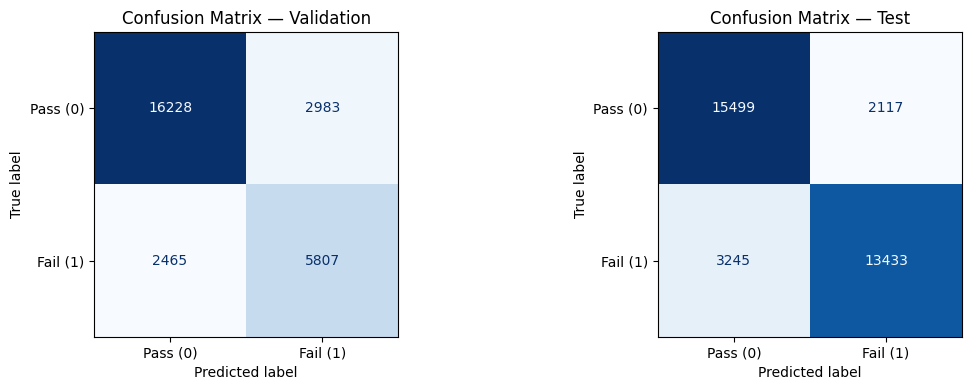

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (y_true, y_pred, title) in zip(axes, [
    (y_val,  val_preds,  'Validation'),
    (y_test, test_preds, 'Test'),
]):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Pass (0)', 'Fail (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {title}')

plt.tight_layout()
plt.savefig('../../reports/figures/dt_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance

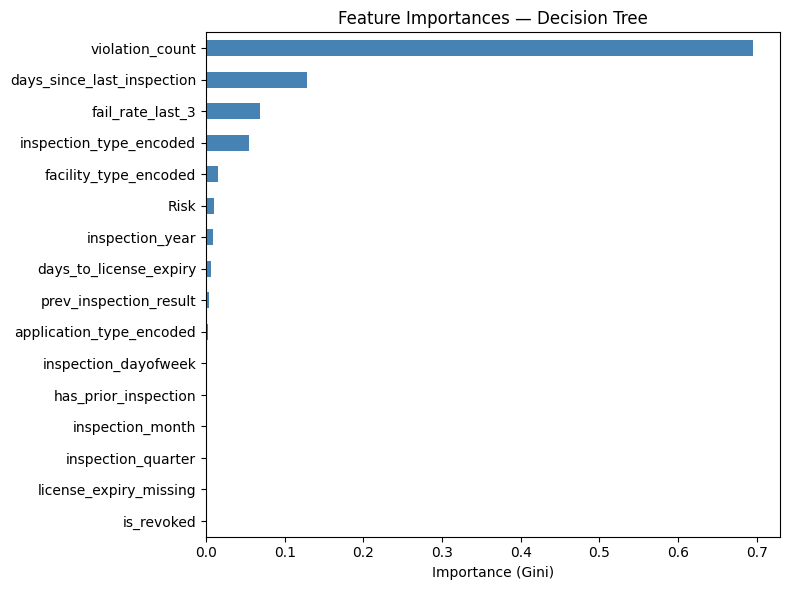


Top 5 most important features:
violation_count               0.694615
days_since_last_inspection    0.128413
fail_rate_last_3              0.068182
inspection_type_encoded       0.054966
facility_type_encoded         0.014833
dtype: float64


In [11]:
importances = pd.Series(
    best_dt.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances — Decision Tree')
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.savefig('../../reports/figures/dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(importances.sort_values(ascending=False).head())

## 9. Visualize the Tree (Top 3 Levels)
Capped at `max_depth=3` for readability

Read top-down. Each node shows:
- **Condition**: the question asked (e.g., `violation_count <= 3.5`)
- **Entropy**: how mixed the classes are at this node (0 = pure, 1 = perfectly mixed)
- **Samples**: how many training rows reach this node
- **Value**: `[Pass count, Fail count]` at this node
- **Class**: the majority class (what would be predicted if we stopped here)

Orange nodes --> majority Pass. Blue nodes --> majority Fail.

The root split on `days_since_last_inspection <= 35.5` means the single most informative
first question is: *"Has this restaurant been inspected in the last 35 days?"*

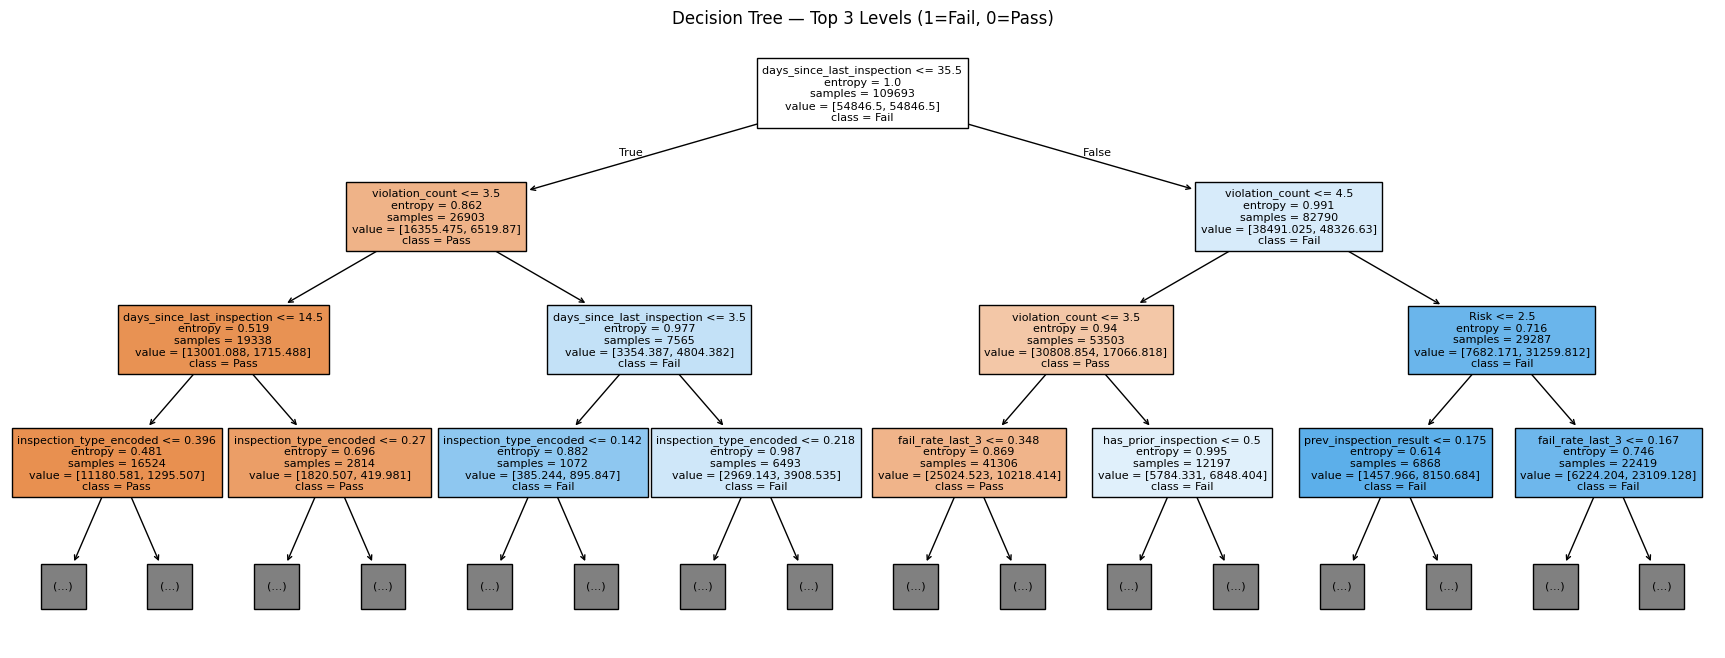

In [14]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    best_dt,
    feature_names=X_train.columns.tolist(),
    class_names=['Pass', 'Fail'],
    filled=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
plt.title('Decision Tree — Top 3 Levels (1=Fail, 0=Pass)')
plt.savefig('../../reports/figures/dt_tree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Final Summary

In [13]:
print('=== Decision Tree — Final Summary ===')
print(f'Target encoding : 1 = Fail, 0 = Pass')
print(f'Best criterion  : {best_params["criterion"]}')
print(f'Best max_depth  : {best_params["max_depth"]}')
print(f'Tree depth      : {best_dt.get_depth()}')
print(f'Leaf nodes      : {best_dt.get_n_leaves()}')
print()
display(summary)

=== Decision Tree — Final Summary ===
Target encoding : 1 = Fail, 0 = Pass
Best criterion  : entropy
Best max_depth  : 8
Tree depth      : 8
Leaf nodes      : 204



,Accuracy,F1 (weighted),F1 — Fail (1),ROC-AUC
Split,,,,
Train,0.7535,0.7627,0.6519,0.8441
Val,0.8018,0.8034,0.6807,0.8587
Test,0.8436,0.8433,0.8336,0.9213
